In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from dating import plot_df, plot_two_columns, data_sampler
from objects import Task, PV, FC, Battery, H2Tank
import os
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

with open("config.json", "r", encoding="utf-8") as datei:
    config = json.load(datei)

# create save_dir:
os.makedirs(config["save_dir"], exist_ok=True)

# Save copy of config in save_dir: 
path = os.path.join(config["save_dir"],config["results_name"]+"_config.json")
with open(path, "w", encoding="utf-8") as datei:
    json.dump(config, datei, ensure_ascii=False, indent=4)  # schön formatiert


# Datei einlesen
file_path = config["solar_data_dir"]

# Zeilen einlesen und 'eor' entfernen
with open(file_path, 'r') as f:
    lines = f.readlines()

# Header aus der ersten Zeile extrahieren
header = lines[0].strip().replace(' ', '').split(';')

# Daten aufbereiten
data = []
for line in lines[1:]:
    line = line.replace('eor', '').strip()
    if line:
        row = [x.strip() for x in line.split(';')]
        data.append(row)

# DataFrame erstellen
df = pd.DataFrame(data, columns=header)

# Numerische Spalten umwandeln
numeric_cols = ['STATIONS_ID', 'QN', 'DS_10', 'GS_10', 'SD_10', 'LS_10']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# -999 als NaN behandeln
df.replace(-999, np.nan, inplace=True)

# MESS_DATUM in datetime umwandeln
df['MESS_DATUM'] = pd.to_datetime(df['MESS_DATUM'], format='%Y%m%d%H%M')
df['DS_10'] *= 10000/3600*6 /1000
df['GS_10'] *= 10000/3600*6 /1000  #J/m² per 10 min

# 29. Februar herausfiltern
df = df[~((df['MESS_DATUM'].dt.month == 2) & (df['MESS_DATUM'].dt.day == 29))]

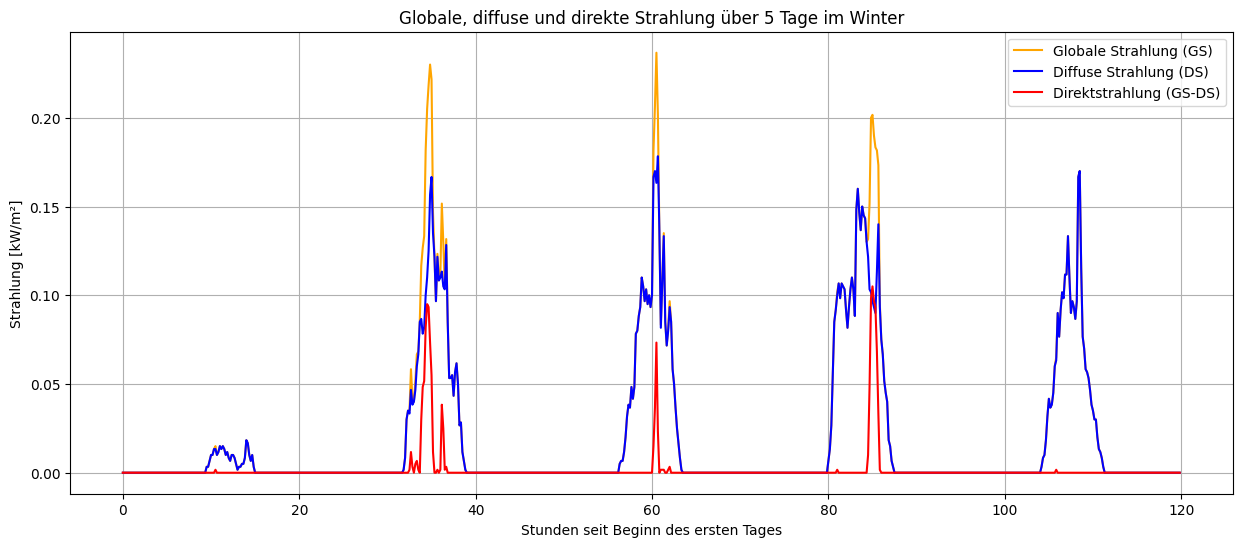

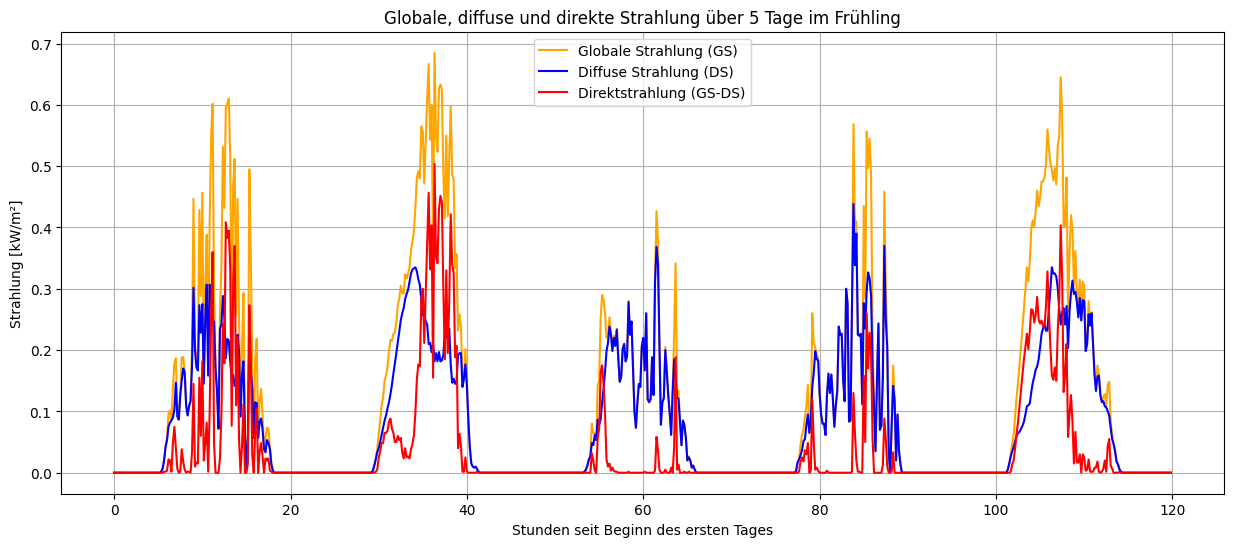

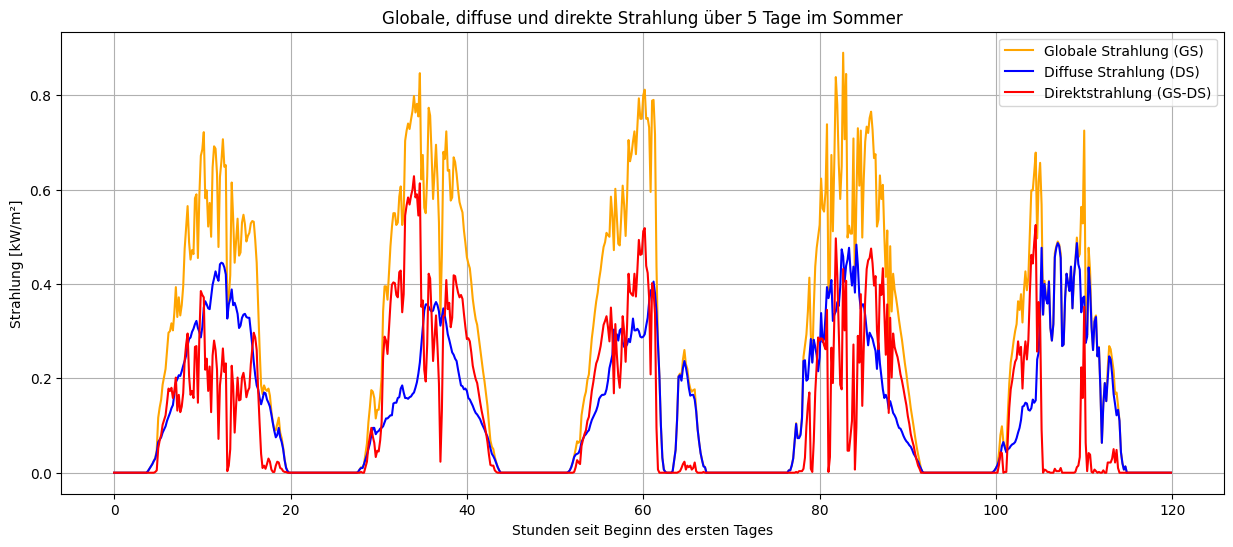

In [2]:
import matplotlib.pyplot as plt

def plot_continuous_solar_with_direct(df, month, season_name):
    # Alle Daten des Monats auswählen
    month_data = df[df['MESS_DATUM'].dt.month == month].copy()
    
    # 5 aufeinanderfolgende Tage auswählen
    days = month_data['MESS_DATUM'].dt.date.unique()
    if len(days) < 5:
        print(f"Nicht genug Daten für {season_name}")
        return
    selected_days = days[:5]  # die ersten 5 Tage
    
    data_5days = month_data[month_data['MESS_DATUM'].dt.date.isin(selected_days)].copy()
    
    # Zeit als fortlaufende Stunden über 5 Tage
    start_time = data_5days['MESS_DATUM'].min()
    data_5days['hours_since_start'] = (data_5days['MESS_DATUM'] - start_time).dt.total_seconds() / 3600
    
    # Direktstrahlung berechnen
    data_5days['Direct'] = data_5days['GS_10'] - data_5days['DS_10']
    
    # Plot erstellen
    plt.figure(figsize=(15,6))
    plt.plot(data_5days['hours_since_start'], data_5days['GS_10'], label='Globale Strahlung (GS)', color='orange')
    plt.plot(data_5days['hours_since_start'], data_5days['DS_10'], label='Diffuse Strahlung (DS)', color='blue')
    plt.plot(data_5days['hours_since_start'], data_5days['Direct'], label='Direktstrahlung (GS-DS)', color='red')
    
    plt.title(f"Globale, diffuse und direkte Strahlung über 5 Tage im {season_name}")
    plt.xlabel("Stunden seit Beginn des ersten Tages")
    plt.ylabel("Strahlung [kW/m²]")
    plt.legend()
    plt.grid(True)
    plt.show()

# Winter: Januar
plot_continuous_solar_with_direct(df, 1, "Winter")

# Frühling: April
plot_continuous_solar_with_direct(df, 4, "Frühling")

# Sommer: Juli
plot_continuous_solar_with_direct(df, 7, "Sommer")

In [3]:
import numpy as np
import pandas as pd

# Tagesweise summieren, NaN in einem Tag → gesamte Summe = NaN
def daily_sum_array(df, column, days_per_year=365, years=10):
    daily_sums = df.groupby(df['MESS_DATUM'].dt.date)[column].agg(
        lambda x: np.nan if x.isna().any() else x.sum()
    ).reset_index()
    daily_sums.columns = ['Date', f'{column}_sum']
    daily_array = daily_sums[f'{column}_sum'].to_numpy().reshape((years, days_per_year))
    daily_array /= 6  # 10-min Werte → kWh/Tag
    return daily_array

# Arrays erstellen
gs_array = daily_sum_array(df, 'GS_10')
ds_array = daily_sum_array(df, 'DS_10')
direct_array = gs_array - ds_array

# Funktion, um dynamisch rollende Shifts zu erzeugen
def create_shift_array(array, max_shift=3):
    """
    array: shape (years, days)
    max_shift: z.B. 3 → erzeugt ±1, ±2, ±3
    """
    arrays = [array]  # Original
    for shift in range(1, max_shift+1):
        arrays.append(np.roll(array, shift, axis=1))   # +shift
        arrays.append(np.roll(array, -shift, axis=1))  # -shift
    return np.vstack(arrays)

# Beispiel: max_shift=3
max_shift = 3
gs_concat = create_shift_array(gs_array, max_shift)
ds_concat = create_shift_array(ds_array, max_shift)
direct_concat = create_shift_array(direct_array, max_shift)

print("GS shape:", gs_concat.shape)
print("DS shape:", ds_concat.shape)
print("Direct shape:", direct_concat.shape)

GS shape: (70, 365)
DS shape: (70, 365)
Direct shape: (70, 365)


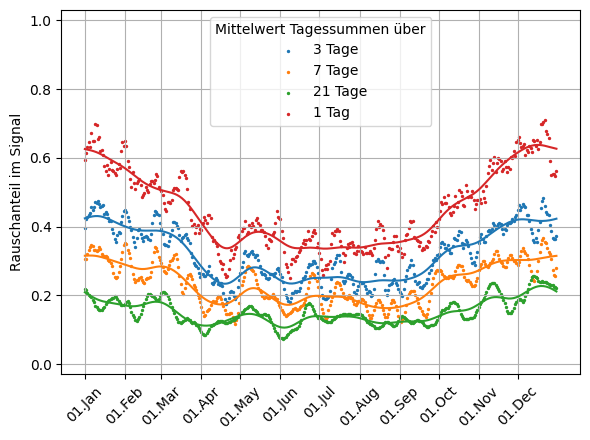

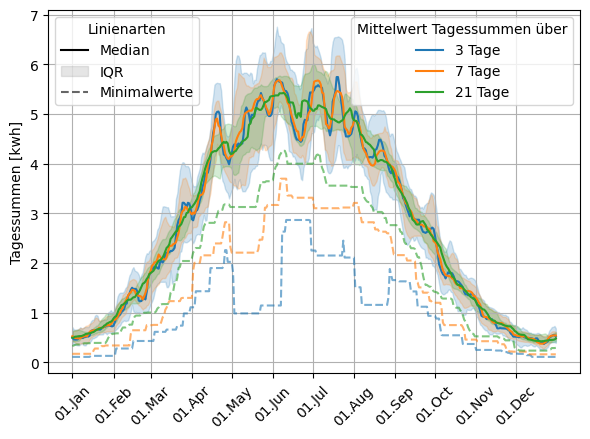

In [4]:
gs10_array = gs_concat

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import convolve2d
import calendar

# Monatsanfänge (Nicht-Schaltjahr)
month_starts = []
month_labels = []

day_counter = 0
for month in range(1, 13):
    month_starts.append(day_counter)
    month_labels.append(f"01.{calendar.month_abbr[month]}")
    day_counter += calendar.monthrange(2023, month)[1]

# ---- 1. Plot: Noise-to-Signal-Ratio ----
plt.figure(figsize=(6, 4.5))
for k in [3,7,21,1]:
    kernel = np.ones((1,k))/k
    result = convolve2d(gs10_array, kernel, mode='same', boundary='wrap')

    mittelwert = np.nanmean(result, axis=0)
    std = np.nanstd(result, axis=0, ddof=1)
    snr = std / mittelwert
    lfsnr = gaussian_filter1d(snr, 10, mode="wrap")

    if k == 1:
        plt.scatter(np.arange(len(snr)), snr, s=2, label=f'{k} Tag')
    else:
        plt.scatter(np.arange(len(snr)), snr, s=2, label=f'{k} Tage')
    plt.plot(lfsnr)

#plt.title("Noise-to-Signal Ratio")
plt.ylim(-0.03, 1.03)
plt.ylabel('Rauschanteil im Signal')
plt.grid(True)
plt.xticks(month_starts, month_labels, rotation=45)
plt.legend(title='Mittelwert Tagessummen über')
plt.tight_layout()
plt.savefig('Noise-Signal-Ratio.pdf')

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d



plt.figure(figsize=(6, 4.5))
ax = plt.gca()  # Achse für doppelte Legende

# Dummy-Handles für die Statistiktypen
dummy_min, = plt.plot([], [], linestyle='--', color='black', alpha=0.6)
dummy_median, = plt.plot([], [], linestyle='-', color='black')
dummy_iqr = plt.fill_between([], [], [], color='gray', alpha=0.2)

for k in [3, 7, 21]:
    kernel = np.ones((1, k)) / k
    result = convolve2d(gs10_array, kernel, mode='same', boundary='wrap')

    median = np.nanmedian(result, axis=0)
    q1 = np.nanpercentile(result, 25, axis=0)
    q3 = np.nanpercentile(result, 75, axis=0)
    minimum = np.nanmin(result, axis=0)

    # Sliding window für Min
    window_size = 14
    extended = np.concatenate([minimum[-(window_size-1):], minimum, minimum[:window_size-1]])
    sliding_min = np.min(np.lib.stride_tricks.sliding_window_view(extended, window_size), axis=1)
    sliding_min = sliding_min[(window_size-1)//2 : -(window_size//2)]

    x = np.arange(len(median))
    
    # Median-Linie
    line, = plt.plot(x, median, label=f"{k} Tage")
    color = line.get_color()

    # Fläche IQR
    plt.fill_between(x, q1, q3, color=color, alpha=0.2)

    # Min-Linie
    plt.plot(x, sliding_min, linestyle='--', color=color, alpha=0.6)

plt.grid(True)
plt.xticks(month_starts, month_labels, rotation=45)

# Erste Legende: Statistiktypen
legend1 = plt.legend(
    handles=[dummy_median, dummy_iqr, dummy_min],
    labels=['Median', 'IQR','Minimalwerte'],
    title='Linienarten',
    loc='upper left'
)
ax.add_artist(legend1)  # Die erste Legende fixieren

# Zweite Legende: k-Tage Labels
plt.legend(title='Mittelwert Tagessummen über')
plt.ylabel("Tagessummen [kwh]")
plt.tight_layout()
plt.savefig('Tagessummen_Median_IQR.pdf')
plt.show()


In [5]:
# import numpy as np
# import matplotlib.pyplot as plt
# import scipy.stats as stats

# equal = np.sort(np.random.random(1000)+2)
# normal = np.sort(np.random.normal(0,1,1000))

# x = np.arange(len(normal))/len(normal)
# plt.scatter(normal,equal)
# plt.show()

# plt.figure(figsize=(6,6))
# stats.probplot(equal, dist="norm", plot=plt)
# plt.xlabel("Theoretische Quantile")
# plt.ylabel("Beobachtete Quantile")
# plt.grid(True)
# plt.show()


(365, 4)
[0.00128509 0.31999735 0.05938345 0.530949  ]


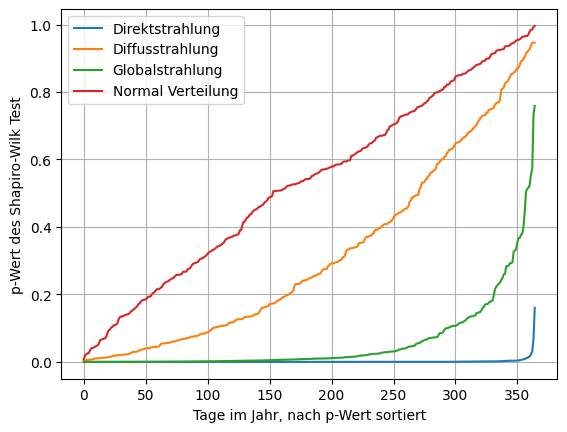

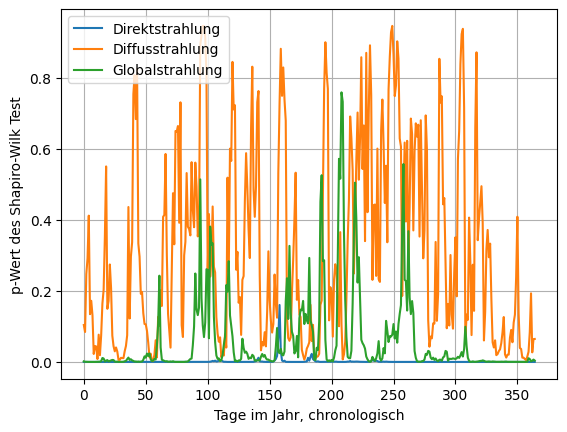

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

plist = []

for k in np.arange(0,365):
    args_gs = np.isnan(gs_concat[:,k])
    args_ds = np.isnan(ds_concat[:,k])
    args_direct = np.isnan(direct_concat[:,k])
    

    stat_ds, p_ds = stats.shapiro(ds_concat[~args_ds][:,k])
    stat_gs, p_gs = stats.shapiro(gs_concat[~args_gs][:,k])
    stat_direct, p_direct = stats.shapiro(direct_concat[~args_direct][:,k])
    comp = np.random.normal(0,1,gs_concat.shape[1])
    stat, p = stats.shapiro(comp)
    plist.append(np.array([p_direct,p_ds,p_gs,p]))


plist = np.array(plist)
print(plist.shape)

print(np.mean(plist,axis=0))

plt.plot(np.sort(plist[:,0],axis=0), label='Direktstrahlung')
plt.plot(np.sort(plist[:,1],axis=0), label='Diffusstrahlung')
plt.plot(np.sort(plist[:,2],axis=0), label='Globalstrahlung')
plt.plot(np.sort(plist[:,3],axis=0), label='Normal Verteilung')
plt.xlabel('Tage im Jahr, nach p-Wert sortiert')
plt.ylabel('p-Wert des Shapiro-Wilk Test')
plt.grid(True)
plt.legend()
plt.savefig("p-Wert_sortiert.pdf")
plt.show()

plt.plot(plist[:,0], label='Direktstrahlung')
plt.plot(plist[:,1], label='Diffusstrahlung')
plt.plot(plist[:,2], label='Globalstrahlung')
#plt.plot(plist[:,3], label='Normal Verteilung')
plt.xlabel('Tage im Jahr, chronologisch')
plt.ylabel('p-Wert des Shapiro-Wilk Test')
plt.grid(True)
plt.legend()
plt.savefig("p-Wert_chronologisch.pdf")
plt.show()

die p-Werte für für das Ganze Jahr sind:
Global: 3.626969488124364e-39
Diffus: 5.227279042566055e-34
Direkt: 2.2920525232648424e-55


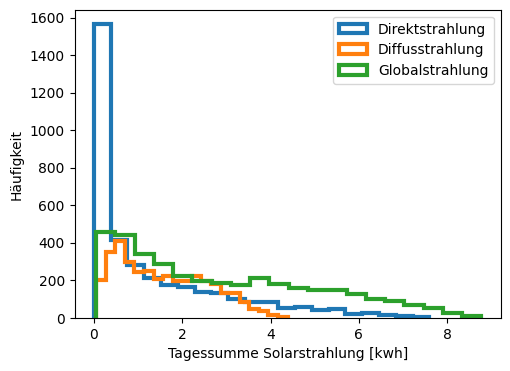

In [7]:
args_gs = np.isnan(gs_array)
args_ds = np.isnan(ds_array)
args_direct = np.isnan(direct_array)


stat_gs, p_gs = stats.shapiro(gs_array[~args_gs])
stat_ds, p_ds = stats.shapiro(ds_array[~args_ds])
stat_direct, p_direct = stats.shapiro(direct_array[~args_direct])
print(f'die p-Werte für für das Ganze Jahr sind:')
print(f'Global: {p_gs}')
print(f'Diffus: {p_ds}')
print(f'Direkt: {p_direct}')

plt.figure(figsize=(5.5, 4))
plt.hist(direct_array.flatten(),bins=20,histtype='step',lw=3,label='Direktstrahlung')
plt.hist(ds_array.flatten(),bins=20,histtype='step',lw=3,label='Diffusstrahlung')
plt.hist(gs_array.flatten(),bins=20,histtype='step',lw=3,label='Globalstrahlung')
plt.xlabel('Tagessumme Solarstrahlung [kwh]')
plt.ylabel('Häufigkeit')
plt.legend()
plt.savefig('Histogramm_year.pdf')
plt.show()


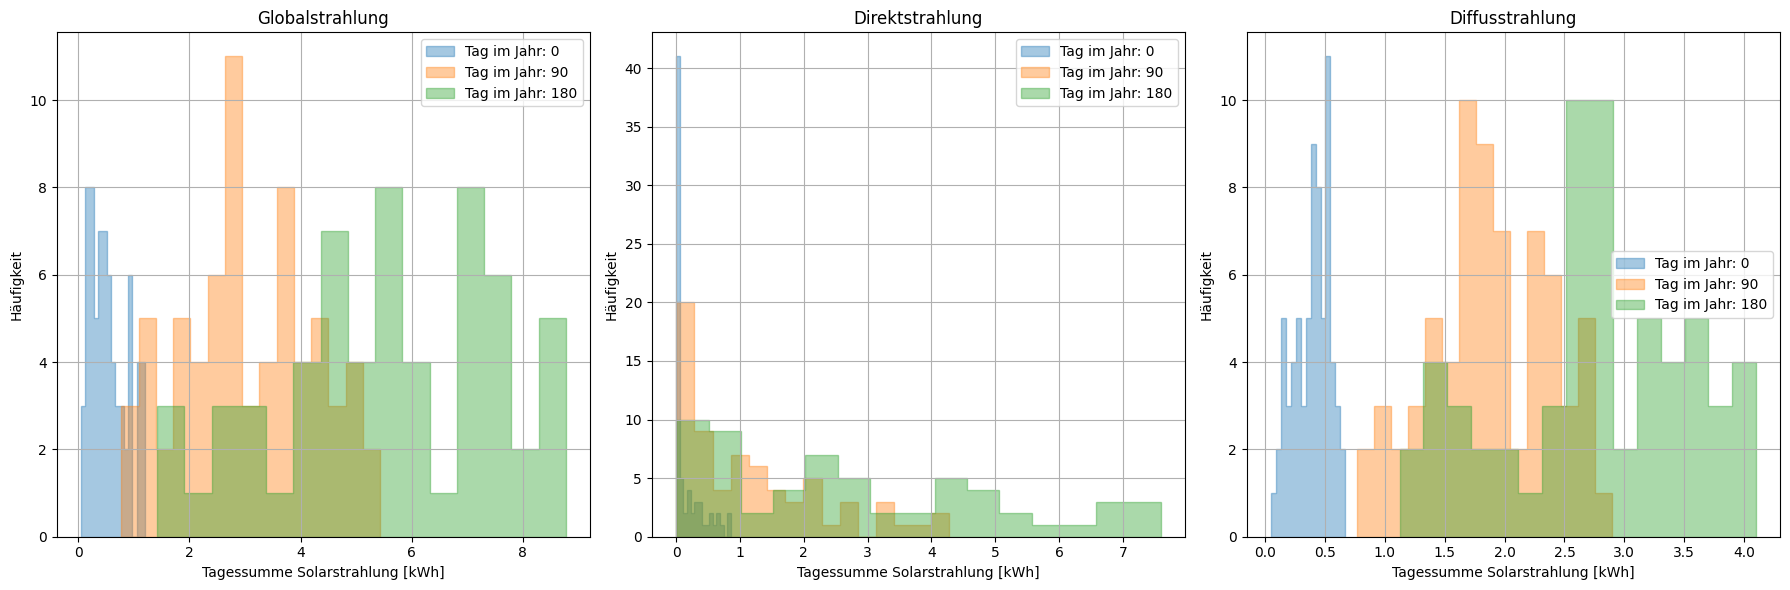

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Farben für unterschiedliche k-Werte
farben = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Erstelle eine Figur mit 3 nebeneinanderliegenden Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 Reihe, 3 Spalten


# Plot 2: Globalstrahlung
for i, k in enumerate(np.arange(0, 260, 90)):
    args = np.isnan(gs_concat[:, k])
    data = gs_concat[~args][:, k]
    axes[0].hist(data, bins=15, histtype='stepfilled', color=farben[i],
                 alpha=0.4, label=f'Tag im Jahr: {k}', edgecolor=farben[i])
axes[0].set_title("Globalstrahlung")
axes[0].set_xlabel("Tagessumme Solarstrahlung [kWh]")
axes[0].set_ylabel("Häufigkeit")
axes[0].grid(True)
axes[0].legend()

# Plot 1: Direktstrahlung
for i, k in enumerate(np.arange(0, 260, 90)):
    args_direct = np.isnan(direct_concat[:, k])
    data = direct_concat[~args_direct][:, k]
    axes[1].hist(data, bins=15, histtype='stepfilled', color=farben[i],
                 alpha=0.4, label=f'Tag im Jahr: {k}', edgecolor=farben[i])
axes[1].set_title("Direktstrahlung")
axes[1].set_xlabel("Tagessumme Solarstrahlung [kWh]")
axes[1].set_ylabel("Häufigkeit")
axes[1].grid(True)
axes[1].legend()

# Plot 3: Diffusstrahlung
for i, k in enumerate(np.arange(0, 260, 90)):
    args = np.isnan(ds_concat[:, k])
    data = ds_concat[~args][:, k]
    axes[2].hist(data, bins=15, histtype='stepfilled', color=farben[i],
                 alpha=0.4, label=f'Tag im Jahr: {k}', edgecolor=farben[i])
axes[2].set_title("Diffusstrahlung")
axes[2].set_xlabel("Tagessumme Solarstrahlung [kWh]")
axes[2].set_ylabel("Häufigkeit")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.savefig("Histogramme_Nebeneinander.pdf")
plt.show()

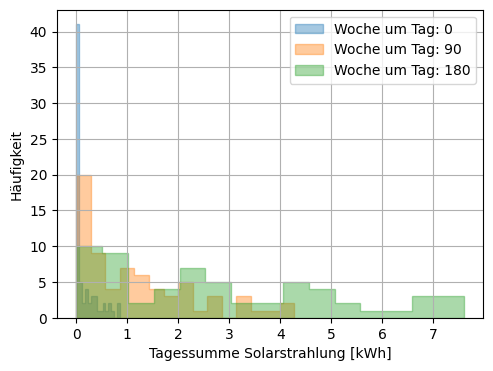

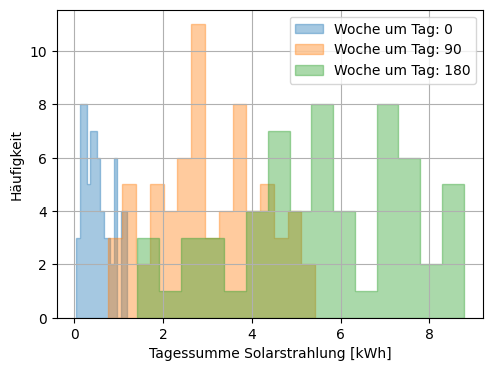

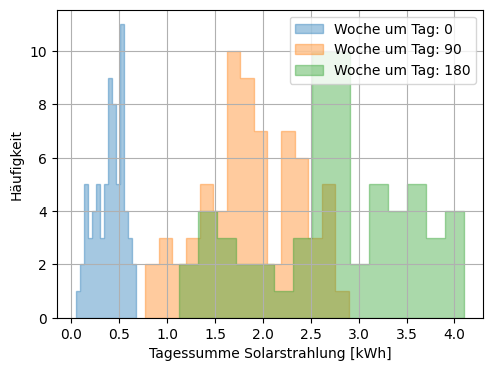

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Farben für unterschiedliche k-Werte
farben = plt.rcParams['axes.prop_cycle'].by_key()['color']
# 1️⃣ Histogramm mit mehreren Kurven
plt.figure(figsize=(5.5, 4))
for i, k in enumerate(np.arange(0, 260, 90)):
    args_direct = np.isnan(direct_concat[:, k])
    data = direct_concat[~args_direct][:, k]
    plt.hist(data, bins=15, histtype='stepfilled', color=farben[i], alpha=0.4, label=f'Woche um Tag: {k}', edgecolor=farben[i])
plt.xlabel("Tagessumme Solarstrahlung [kWh]")
plt.ylabel("Häufigkeit")
plt.grid(True)
plt.legend()
plt.savefig("Hist_DirektStrahlung.pdf")
plt.show()

# Farben für unterschiedliche k-Werte
farben = plt.rcParams['axes.prop_cycle'].by_key()['color']
# 1️⃣ Histogramm mit mehreren Kurven
plt.figure(figsize=(5.5, 4))
for i, k in enumerate(np.arange(0, 260, 90)):
    args = np.isnan(gs_concat[:, k])
    data = gs_concat[~args][:, k]
    plt.hist(data, bins=15, histtype='stepfilled', color=farben[i], alpha=0.4, label=f'Woche um Tag: {k}', edgecolor=farben[i])
plt.xlabel("Tagessumme Solarstrahlung [kWh]")
plt.ylabel("Häufigkeit")
plt.grid(True)
plt.legend()
plt.savefig("Hist_Globalstrahlung.pdf")
plt.show()

# Farben für unterschiedliche k-Werte
farben = plt.rcParams['axes.prop_cycle'].by_key()['color']
# 1️⃣ Histogramm mit mehreren Kurven
plt.figure(figsize=(5.5, 4))
for i, k in enumerate(np.arange(0, 260, 90)):
    args = np.isnan(ds_concat[:, k])
    data = ds_concat[~args][:, k]
    plt.hist(data, bins=15, histtype='stepfilled', color=farben[i], alpha=0.4, label=f'Woche um Tag: {k}', edgecolor=farben[i])
plt.xlabel("Tagessumme Solarstrahlung [kWh]")
plt.ylabel("Häufigkeit")
plt.grid(True)
plt.legend()
plt.savefig("Hist_Diffusstrahlung.pdf")
plt.show()

# # 2️⃣ QQ-Plot Normalverteilung mit mehreren Kurven
# plt.figure(figsize=(8,6))
# for i, k in enumerate(np.arange(0, 260, 90)):
#     args_direct = np.isnan(direct_concat[:, k])
#     data = gs_concat[~args_direct][:, k]
#     (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
#     plt.plot(osm, osr, 'o', color=farben[i], label=f'k={k}')
#     plt.plot(osm, slope*osm + intercept, '--', color=farben[i])
# plt.title("QQ-Plot Normalverteilung (mehrere Kurven)")
# plt.xlabel("Theoretische Quantile (Normalverteilung)")
# plt.ylabel("Beobachtete Quantile")
# plt.grid(True)
# plt.legend()
# plt.show()

# # 3️⃣ QQ-Plot Gleichverteilung mit mehreren Kurven
# plt.figure(figsize=(8,6))
# for i, k in enumerate(np.arange(0, 260, 90)):
#     args_direct = np.isnan(direct_concat[:, k])
#     data = gs_concat[~args_direct][:, k]
#     (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="uniform")
#     plt.plot(osm, osr, 'o', color=farben[i], label=f'k={k}')
#     plt.plot(osm, slope*osm + intercept, '--', color=farben[i])
# plt.title("QQ-Plot Gleichverteilung (mehrere Kurven)")
# plt.xlabel("Theoretische Quantile (Gleichverteilung)")
# plt.ylabel("Beobachtete Quantile")
# plt.grid(True)
# plt.legend()
# plt.show()

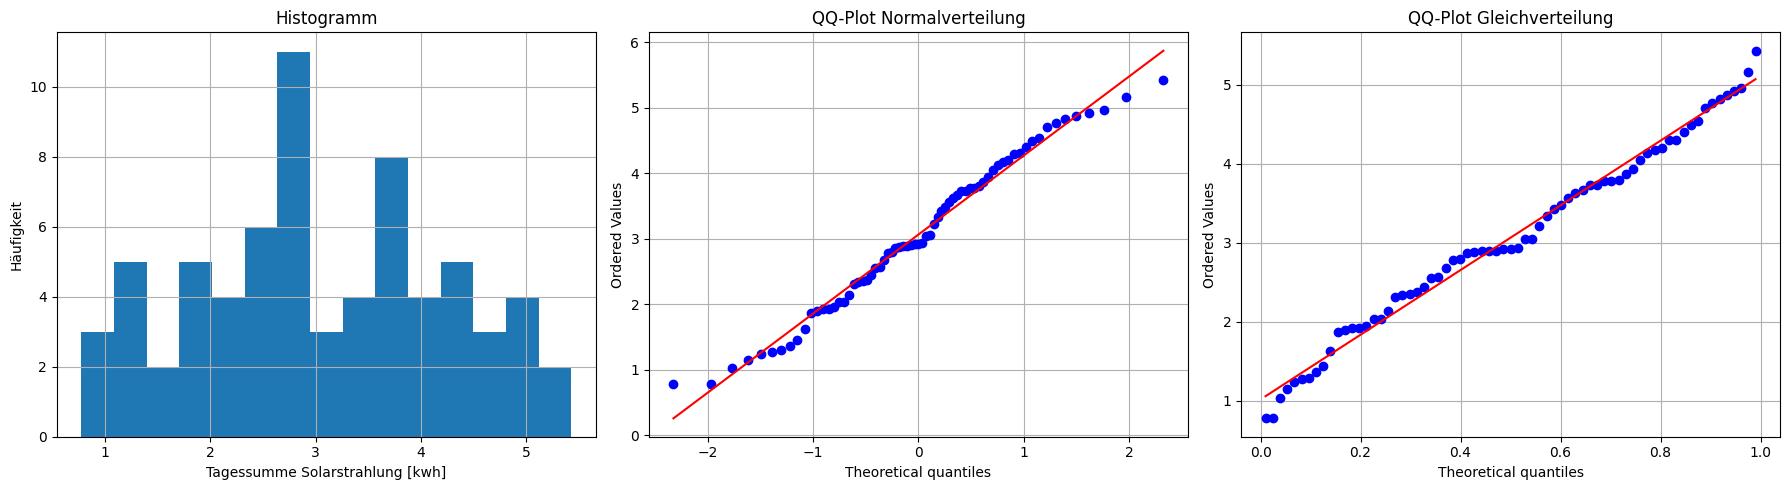

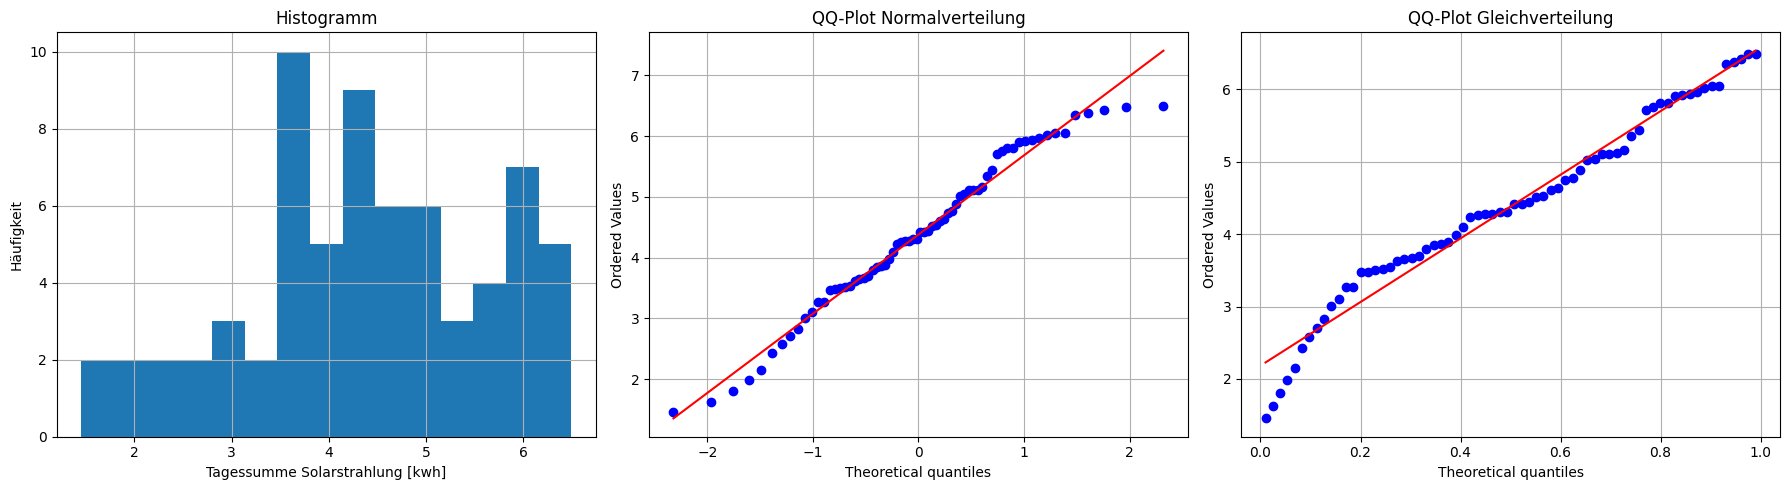

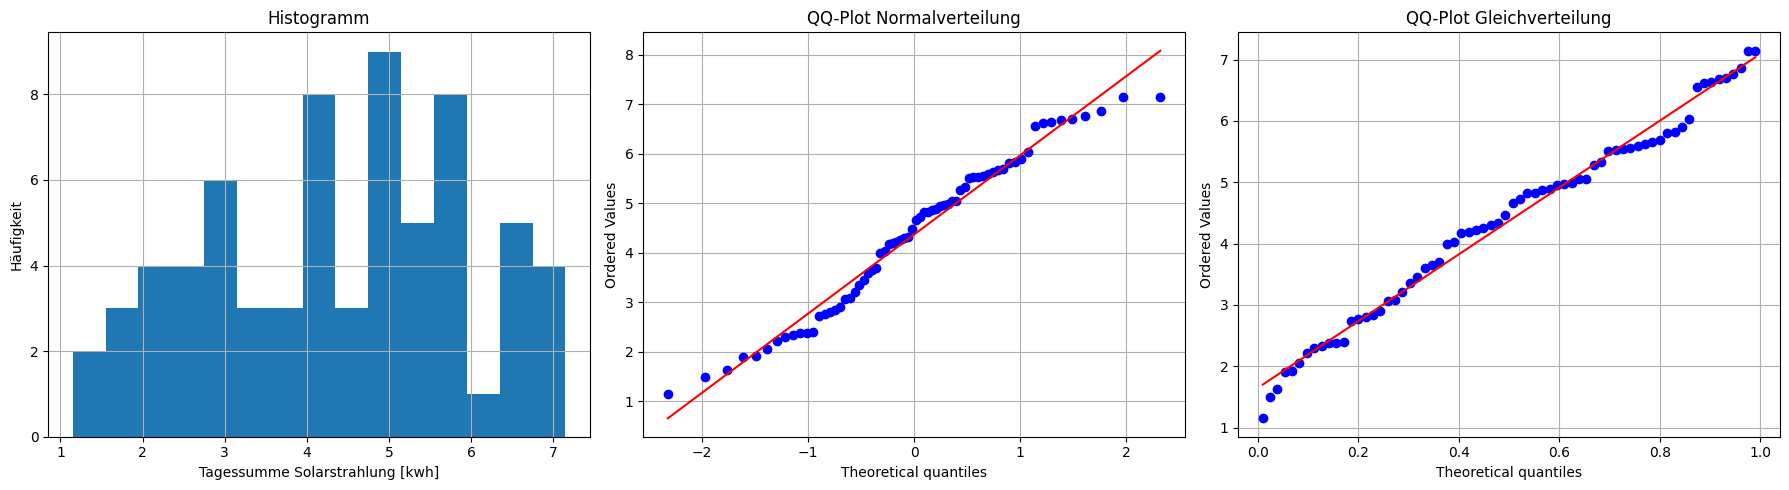

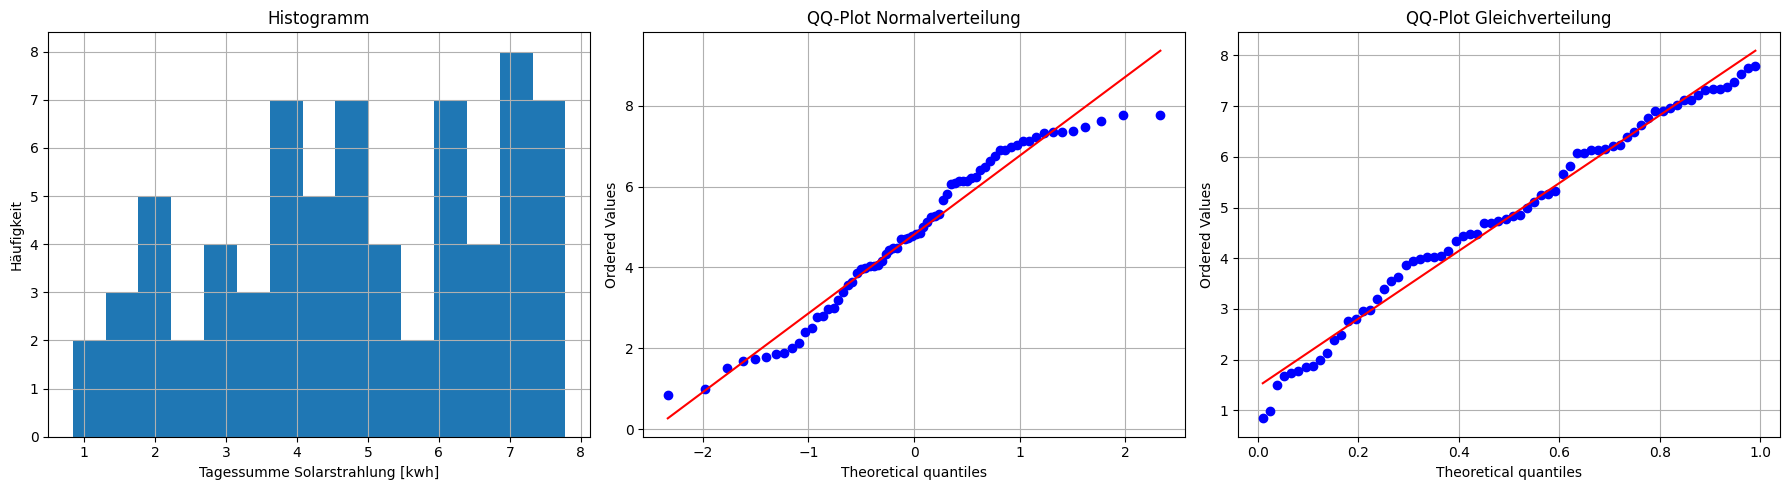

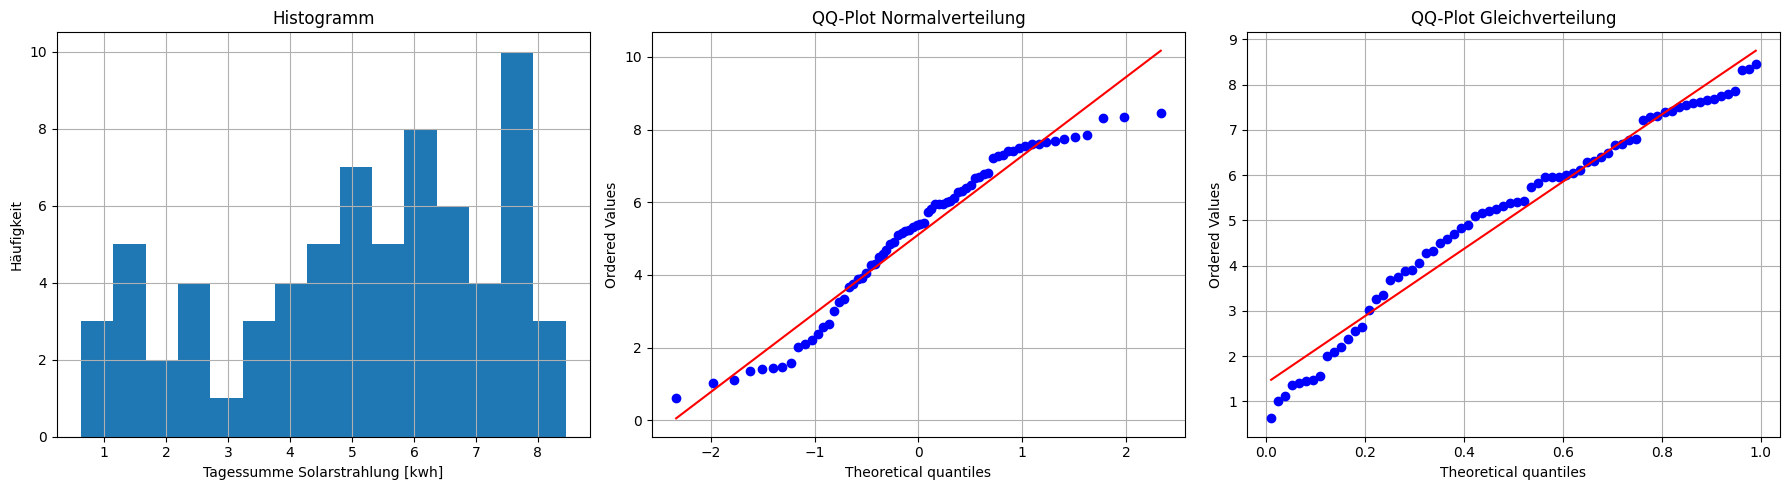

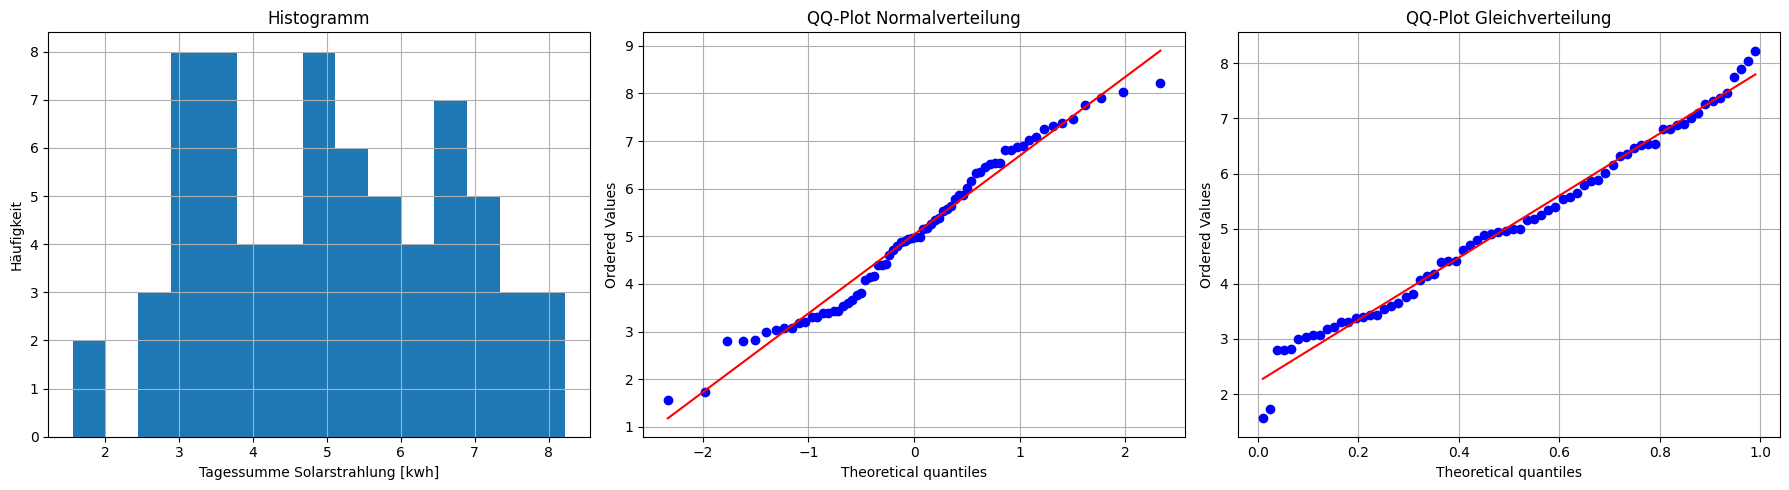

In [10]:
for k in np.arange(90,180,15):
    args_direct = np.isnan(direct_concat[:,k])
    
    fig, axes = plt.subplots(1, 3, figsize=(18,5))


    data = gs_concat[~args_direct][:,k]
    # 1️⃣ Histogramm
    axes[0].hist(data, bins=15)
    axes[0].set_title("Histogramm")
    axes[0].set_xlabel('Tagessumme Solarstrahlung [kwh]')
    axes[0].set_ylabel("Häufigkeit")
    axes[0].grid(True)

    # 2️⃣ QQ-Plot Normalverteilung
    stats.probplot(data, dist="norm", plot=axes[1])
    axes[1].set_title("QQ-Plot Normalverteilung")
    axes[1].grid(True)

    # 3️⃣ QQ-Plot Gleichverteilung
    stats.probplot(data, dist="uniform", plot=axes[2])
    axes[2].set_title("QQ-Plot Gleichverteilung")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()